# Project Phase II: Applied Data Engineering and Machine Learning

In [331]:
import pandas as pd

# Load the raw dataset and create a deep copy for further processing
df = pd.read_csv("../data/student-course-completion-prediction-dataset-trimmed.csv")
df_copy = df.copy(deep=True)

display(df_copy.head())

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [332]:
for col in df_copy.columns:
    print(f"{col}: {df_copy[col].dtype}, unique: {df_copy[col].nunique(dropna=True)}")

Student_ID: str, unique: 30000
Name: str, unique: 300
Gender: str, unique: 3
Age: int64, unique: 33
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 16
Average_Session_Duration_Min: int64, unique: 72
Video_Completion_Rate: float64, unique: 929
Discussion_Participation: int64, unique: 13
Time_Spent_Hours: float64, unique: 209
Days_Since_Last_Login: int64, unique: 71
Notifications_Checked: int64, unique: 19
Peer_Interaction_Score: float64, unique: 101
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 16
Quiz_Score_Avg: float64, unique: 668
Project_Grade: float64, unique: 811
Progress_Percentage: float64, uni

### Data Preprocessing and Feature Engineering

In [333]:
# Check and correct incorrect data types
print("=== Normalizing Data Types ===\n")

integer_columns = [
    "Age",
    "Course_Duration_Days",
    "Login_Frequency",
    "Average_Session_Duration_Min",
    "Discussion_Participation",
    "Days_Since_Last_Login",
    "Notifications_Checked",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Rewatch_Count",
    "Payment_Amount",
    "App_Usage_Percentage",
    "Reminder_Emails_Clicked",
    "Support_Tickets_Raised",
]
float_columns = [
    "Instructor_Rating",
    "Video_Completion_Rate",
    "Time_Spent_Hours",
    "Peer_Interaction_Score",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
    "Satisfaction_Rating",
    "Attendance_Rate",
]
expected_numeric_dtypes = {
    **dict.fromkeys(integer_columns, "int64"),
    **dict.fromkeys(float_columns, "float64"),
}

for column_name, expected_dtype in expected_numeric_dtypes.items():
    if column_name not in df_copy.columns:
        continue

    original_values = df_copy[column_name]
    converted_values = pd.to_numeric(original_values, errors="coerce")
    invalid_mask = original_values.notna() & converted_values.isna()

    if invalid_mask.any():
        examples = original_values[invalid_mask].head(5).tolist()
        print(
            f"{column_name}: {invalid_mask.sum()} values could not be converted "
            f"to {expected_dtype}; examples: {examples}"
        )

    fractional_mask = converted_values.notna() & converted_values.mod(1).ne(0)
    if expected_dtype == "int64" and fractional_mask.any():
        print(
            f"{column_name}: {fractional_mask.sum()} fractional values found; "
            "preserving the column as float64"
        )
        df_copy[column_name] = converted_values.astype("float64")
    elif expected_dtype == "int64" and not converted_values.isna().any():
        df_copy[column_name] = converted_values.astype("int64")
    else:
        df_copy[column_name] = converted_values.astype("float64")

# Dataset dates use day-month-year format.
if "Enrollment_Date" in df_copy.columns:
    original_dates = df_copy["Enrollment_Date"]
    parsed_dates = pd.to_datetime(original_dates, format="%d-%m-%Y", errors="coerce")
    invalid_dates = original_dates.notna() & parsed_dates.isna()

    if invalid_dates.any():
        examples = original_dates[invalid_dates].head(5).tolist()
        print(
            f"Enrollment_Date: {invalid_dates.sum()} values could not be parsed; "
            f"examples: {examples}"
        )

    df_copy["Enrollment_Date"] = parsed_dates

print("\nResulting data types:")
print(df_copy.dtypes.to_string())

=== Normalizing Data Types ===


Resulting data types:
Student_ID                                 str
Name                                       str
Gender                                     str
Age                                      int64
Education_Level                            str
Employment_Status                          str
City                                       str
Device_Type                                str
Internet_Connection_Quality                str
Course_ID                                  str
Course_Name                                str
Category                                   str
Course_Level                               str
Course_Duration_Days                     int64
Instructor_Rating                      float64
Login_Frequency                          int64
Average_Session_Duration_Min             int64
Video_Completion_Rate                  float64
Discussion_Participation                 int64
Time_Spent_Hours                       float64
Days_

In [334]:
# Address missing values and duplicate records

# Display duplicate Student_ID records
duplicate_student_rows = df_copy[df_copy["Student_ID"].duplicated(keep=False)]

print("Duplicate records with the same Student_ID:")
if len(duplicate_student_rows) > 0:
    print(duplicate_student_rows.to_string(index=False))
else:
    print("No duplicate Student_ID records found.")

# Display completely identical duplicate records
complete_duplicate_rows = df_copy[df_copy.duplicated(keep=False)]

print("\nComplete duplicate records:")
if len(complete_duplicate_rows) > 0:
    print(complete_duplicate_rows.to_string(index=False))
else:
    print("No complete duplicate records found.")

# Check columns with missing values
missing = df_copy.isna().sum()
missing_columns = missing[missing > 0].sort_values(ascending=False)

print("\nColumns containing missing values:")

if missing_columns.empty:
    print("No missing values found.")
else:
    for column_name, missing_count in missing_columns.items():
        print(f"{column_name}: {missing_count}")

    # Display rows containing missing values
    rows_with_missing = df_copy[df_copy.isna().any(axis=1)]

    print("\nRows containing missing values:")
    print(rows_with_missing.to_string(index=False))

print("\nDataset shape after inspection:")
print(f"Rows: {df_copy.shape[0]}, Columns: {df_copy.shape[1]}")

Duplicate records with the same Student_ID:
No duplicate Student_ID records found.

Complete duplicate records:
No complete duplicate records found.

Columns containing missing values:
No missing values found.

Dataset shape after inspection:
Rows: 30000, Columns: 40


In [335]:
# Inspect and fix invalid values

print("=== Inspecting Invalid Values ===\n")

# Check for negative values in columns that should be non-negative
numeric_cols = df_copy.select_dtypes(include="number").columns

invalid_values_found = False

for col in numeric_cols:
    negative_count = (df_copy[col] < 0).sum()

    if negative_count > 0:
        invalid_values_found = True
        print(f"{col}: {negative_count} negative values found")

        # Show examples of negative values
        negative_examples = df_copy[df_copy[col] < 0][col].head(5).tolist()
        print(f"  Examples: {negative_examples}")

# Check for out-of-range values in percentage columns
if "Attendance_Rate" in df_copy.columns:
    out_of_range = (
        (df_copy["Attendance_Rate"] < 0) | (df_copy["Attendance_Rate"] > 100)
    ).sum()
    if out_of_range > 0:
        invalid_values_found = True
        print(f"Attendance_Rate: {out_of_range} values outside 0-100 range")

if not invalid_values_found:
    print("No invalid numeric values detected.\n")
else:
    print()

# Check for unexpected values in expected binary/categorical columns
binary_cols = {
    "Fee_Paid": ["Yes", "No"],
    "Discount_Used": ["Yes", "No"],
    "Completed": ["Completed", "Not Completed"],
}

print("=== Inspecting Expected Categorical Values ===\n")

categorical_anomalies = False

for col, expected_values in binary_cols.items():
    if col in df_copy.columns:
        actual_values = df_copy[col].unique()
        unexpected = [
            value
            for value in actual_values
            if value not in expected_values and pd.notna(value)
        ]

        if unexpected:
            categorical_anomalies = True
            print(f"{col}: Unexpected values found")
            print(f"  Expected: {expected_values}")
            print(f"  Found: {list(set(unexpected))}")

if not categorical_anomalies:
    print("All categorical columns have expected values.\n")
else:
    print()

# Check for inconsistent categories with case/whitespace variations
print("=== Inspecting Inconsistent Categories ===\n")

category_check_cols = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "City",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_ID",
    "Course_Name",
    "Category",
    "Course_Level",
    "Payment_Mode",
    "Fee_Paid",
    "Discount_Used",
    "Completed",
]

inconsistency_found = False

for col in category_check_cols:
    if col in df_copy.columns:
        original_count = df_copy[col].nunique(dropna=False)

        cleaned_count = (
            df_copy[col].astype("string").str.strip().str.lower().nunique(dropna=False)
        )

        if original_count != cleaned_count:
            inconsistency_found = True
            print(f"{col}: {original_count} original vs {cleaned_count} standardised")

            # Show examples of variations
            original_values = df_copy[col].dropna().unique()[:10]
            print(f"  Sample values: {list(original_values)}")

if not inconsistency_found:
    print("No categorical inconsistencies detected.\n")
else:
    print()

=== Inspecting Invalid Values ===

No invalid numeric values detected.

=== Inspecting Expected Categorical Values ===

All categorical columns have expected values.

=== Inspecting Inconsistent Categories ===

No categorical inconsistencies detected.



In [336]:
# Split before any data-dependent preprocessing to avoid data leakage.
from sklearn.model_selection import train_test_split

if not df_copy["Completed"].isin(["Not Completed", "Completed"]).all():
    raise ValueError("Completed contains labels outside the expected categories.")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_copy.drop(columns=["Completed"]),
    df_copy["Completed"].map({"Not Completed": 0, "Completed": 1}),
    test_size=0.2,
    random_state=42,
    stratify=df_copy["Completed"],
)

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()
initial_train_rows = len(X_train_raw)

print("=== Leakage-Safe Train/Test Split ===")
print(f"Training rows: {len(X_train_raw)}")
print(f"Test rows: {len(X_test_raw)}")
print("Target proportions:")
print("  Train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("  Test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

=== Leakage-Safe Train/Test Split ===
Training rows: 24000
Test rows: 6000
Target proportions:
  Train:
Completed
0    0.507
1    0.493
Name: proportion, dtype: float64
  Test:
Completed
0    0.507
1    0.493
Name: proportion, dtype: float64


In [337]:
# Investigate outliers using training data only
import numpy as np

print("=== Investigating Training-Set Outliers Using IQR Method ===\n")

numeric_cols = X_train_raw.select_dtypes(include="number").columns

valid_ranges = {
    "Age": (17, 60),
    "Instructor_Rating": (0, 5),
    "Satisfaction_Rating": (0, 5),
    "Video_Completion_Rate": (0, 100),
    "Progress_Percentage": (0, 100),
    "App_Usage_Percentage": (0, 100),
    "Quiz_Score_Avg": (0, 100),
    "Project_Grade": (0, 100),
    "Course_Duration_Days": (0, 90),
    "Average_Session_Duration_Min": (0, 80),
    "Time_Spent_Hours": (0, 30),
    "Days_Since_Last_Login": (0, 100),
    "Payment_Amount": (0, None),
}

outlier_summary = {}

for col in numeric_cols:
    training_values = X_train_raw[col]
    q1 = training_values.quantile(0.25)
    q3 = training_values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (training_values < lower_bound) | (training_values > upper_bound)
    outlier_count = outlier_mask.sum()

    range_violations = 0
    if col in valid_ranges:
        min_valid, max_valid = valid_ranges[col]
        if max_valid is None:
            range_mask = training_values < min_valid
        else:
            range_mask = (training_values < min_valid) | (training_values > max_valid)
        range_violations = range_mask.sum()

    outlier_summary[col] = {
        "outlier_count_iqr": outlier_count,
        "outlier_pct": round((outlier_count / len(X_train_raw)) * 100, 2),
        "range_violations": range_violations,
        "min": training_values.min(),
        "max": training_values.max(),
        "mean": training_values.mean(),
        "median": training_values.median(),
        "std": training_values.std(),
        "iqr_bounds": (lower_bound, upper_bound),
    }

print("Training columns with outliers (IQR method > 0.5%):\n")
for col, stats in outlier_summary.items():
    if stats["outlier_pct"] > 0.5 or stats["range_violations"] > 0:
        print(f"{col}:")
        print(
            f"  Min: {stats['min']:.2f}, Max: {stats['max']:.2f}, "
            f"Mean: {stats['mean']:.2f}, Median: {stats['median']:.2f}"
        )
        print(f"  Std Dev: {stats['std']:.2f}")
        print(f"  IQR Outliers: {stats['outlier_count_iqr']} ({stats['outlier_pct']}%)")
        if stats["range_violations"] > 0:
            print(f"  Range Violations: {stats['range_violations']}")
        print(
            f"  IQR Bounds: ({stats['iqr_bounds'][0]:.2f}, "
            f"{stats['iqr_bounds'][1]:.2f})\n"
        )

print("\n=== Identifying Training Records with Range Violations ===\n")
violation_mask = pd.Series(False, index=X_train_raw.index)

for col, (min_val, max_val) in valid_ranges.items():
    if col in X_train_raw.columns:
        if max_val is None:
            col_violation = X_train_raw[col] < min_val
        else:
            col_violation = (X_train_raw[col] < min_val) | (X_train_raw[col] > max_val)
        violation_mask |= col_violation

records_with_violations = X_train_raw.loc[violation_mask]
print(f"Training records with range violations: {len(records_with_violations)}")
if len(X_train_raw) > 0:
    print(
        "Percentage of training set: "
        f"{len(records_with_violations) / len(X_train_raw) * 100:.2f}%\n"
    )

if not records_with_violations.empty:
    print("Sample training records with violations:")
    violation_cols = ["Student_ID"] + list(valid_ranges.keys())
    violation_cols = [
        col for col in violation_cols if col in records_with_violations.columns
    ]
    print(records_with_violations[violation_cols].head(10).to_string(index=False))

=== Investigating Training-Set Outliers Using IQR Method ===

Training columns with outliers (IQR method > 0.5%):

Average_Session_Duration_Min:
  Min: 5.00, Max: 76.00, Mean: 33.88, Median: 34.00
  Std Dev: 10.39
  IQR Outliers: 147 (0.61%)
  IQR Bounds: (6.00, 62.00)

Discussion_Participation:
  Min: 0.00, Max: 11.00, Mean: 2.33, Median: 2.00
  Std Dev: 1.58
  IQR Outliers: 316 (1.32%)
  IQR Bounds: (-2.00, 6.00)

Time_Spent_Hours:
  Min: 0.50, Max: 25.60, Mean: 3.87, Median: 2.70
  Std Dev: 3.79
  IQR Outliers: 231 (0.96%)
  IQR Bounds: (-8.20, 15.00)

Days_Since_Last_Login:
  Min: 0.00, Max: 99.00, Mean: 6.14, Median: 4.00
  Std Dev: 7.06
  IQR Outliers: 957 (3.99%)
  IQR Bounds: (-11.00, 21.00)

Quiz_Attempts:
  Min: 0.00, Max: 15.00, Mean: 3.79, Median: 4.00
  Std Dev: 2.02
  IQR Outliers: 180 (0.75%)
  IQR Bounds: (-2.50, 9.50)

Progress_Percentage:
  Min: 9.70, Max: 97.40, Mean: 53.93, Median: 54.10
  Std Dev: 12.56
  IQR Outliers: 135 (0.56%)
  IQR Bounds: (20.00, 88.00)

Rewa

In [338]:
# Handle outliers without learning from the test set

print("=== Handling Outliers ===\n")

# Apply only predefined domain limits to both splits
percentage_cols = [
    "Video_Completion_Rate",
    "Progress_Percentage",
    "App_Usage_Percentage",
    "Quiz_Score_Avg",
    "Project_Grade",
]

for col in percentage_cols:
    if col in X_train_raw.columns:
        for split_name, split_data in (("train", X_train_raw), ("test", X_test_raw)):
            before_count = ((split_data[col] < 0) | (split_data[col] > 100)).sum()
            split_data[col] = split_data[col].clip(0, 100)
            if before_count > 0:
                print(f"{split_name} {col}: capped {before_count} values to [0, 100]")

rating_cols = ["Instructor_Rating", "Satisfaction_Rating"]
for col in rating_cols:
    if col in X_train_raw.columns:
        for split_name, split_data in (("train", X_train_raw), ("test", X_test_raw)):
            before_count = ((split_data[col] < 0) | (split_data[col] > 5)).sum()
            split_data[col] = split_data[col].clip(0, 5)
            if before_count > 0:
                print(f"{split_name} {col}: capped {before_count} values to [0, 5]")

if "Age" in X_train_raw.columns:
    for split_name, split_data in (("train", X_train_raw), ("test", X_test_raw)):
        before_count = ((split_data["Age"] < 17) | (split_data["Age"] > 80)).sum()
        split_data["Age"] = split_data["Age"].clip(17, 80)
        if before_count > 0:
            print(f"{split_name} Age: capped {before_count} values to [17, 80]")

print("\nRemoving extreme IQR outliers from training data only (k=3):\n")
rows_to_remove = []

for col in numeric_cols:
    training_values = X_train_raw[col]
    q1 = training_values.quantile(0.25)
    q3 = training_values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    extreme_mask = (training_values < lower_bound) | (training_values > upper_bound)

    if extreme_mask.any():
        print(
            f"{col}: {extreme_mask.sum()} training outliers; bounds [{lower_bound:.2f}, {upper_bound:.2f}]"
        )
        rows_to_remove.extend(X_train_raw.index[extreme_mask].tolist())

rows_to_remove = sorted(set(rows_to_remove))
if rows_to_remove:
    X_train_raw = X_train_raw.drop(index=rows_to_remove)
    y_train = y_train.drop(index=rows_to_remove)
    print(f"Removed {len(rows_to_remove)} training rows; test rows remain unchanged.")
else:
    print("No extreme training outliers detected.")

print(f"\nTraining rows retained: {len(X_train_raw)} of {initial_train_rows}")
print(f"Test rows retained: {len(X_test_raw)}")

=== Handling Outliers ===


Removing extreme IQR outliers from training data only (k=3):

Discussion_Participation: 7 training outliers; bounds [-5.00, 9.00]
Time_Spent_Hours: 5 training outliers; bounds [-16.90, 23.70]
Days_Since_Last_Login: 222 training outliers; bounds [-23.00, 33.00]
Quiz_Attempts: 1 training outliers; bounds [-7.00, 14.00]
Rewatch_Count: 13 training outliers; bounds [-5.00, 9.00]
Reminder_Emails_Clicked: 6 training outliers; bounds [-5.00, 9.00]
Support_Tickets_Raised: 49 training outliers; bounds [-3.00, 4.00]
Removed 302 training rows; test rows remain unchanged.

Training rows retained: 23698 of 24000
Test rows retained: 6000


In [339]:
# Final summary after training-only outlier handling
print("=== Data Quality Summary ===\n")
print(f"Rows in source dataframe: {len(df_copy)}")
print(f"Training rows before IQR removal: {initial_train_rows}")
print(
    f"Training rows removed by training-only IQR rule: {initial_train_rows - len(X_train_raw)}"
)
print(f"Training rows retained: {len(X_train_raw)}")
print(f"Test rows retained unchanged: {len(X_test_raw)}\n")

print("Training Numeric Columns Statistics:")
print("-" * 80)
numeric_summary = X_train_raw.select_dtypes(include="number").describe().T.round(2)
print(numeric_summary.to_string())
print("\n" + "=" * 80)
print("Preprocessing statistics are derived from training data only.")

=== Data Quality Summary ===

Rows in source dataframe: 30000
Training rows before IQR removal: 24000
Training rows removed by training-only IQR rule: 302
Training rows retained: 23698
Test rows retained unchanged: 6000

Training Numeric Columns Statistics:
--------------------------------------------------------------------------------
                                count     mean      std   min     25%     50%     75%     max
Age                           23698.0    25.68     5.58  17.0    21.0    25.0    29.0    47.0
Course_Duration_Days          23698.0    51.80    20.32  25.0    30.0    45.0    60.0    90.0
Instructor_Rating             23698.0     4.44     0.20   4.1     4.3     4.5     4.6     4.7
Login_Frequency               23698.0     4.79     1.84   0.0     3.0     5.0     6.0    15.0
Average_Session_Duration_Min  23698.0    33.90    10.38   5.0    27.0    34.0    41.0    76.0
Video_Completion_Rate         23698.0    62.39    19.59   5.0    48.7    64.3    77.8    99.9
Dis

In [340]:
# Encode categorical features using training data only
from sklearn.preprocessing import OrdinalEncoder

print("=== Leakage-Safe Categorical Encoding ===\n")

identifier_cols = ["Student_ID", "Name", "Course_Name", "Enrollment_Date"]
X_train_raw.drop(columns=identifier_cols, errors="ignore", inplace=True)
X_test_raw.drop(columns=identifier_cols, errors="ignore", inplace=True)

categorical_features = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "City",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_ID",
    "Category",
    "Payment_Mode",
    "Fee_Paid",
    "Discount_Used",
]
categorical_features = [
    col for col in categorical_features if col in X_train_raw.columns
]

for col in categorical_features:
    X_train_raw[col] = X_train_raw[col].astype("string").fillna("__MISSING__")
    X_test_raw[col] = X_test_raw[col].astype("string").fillna("__MISSING__")

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)
if categorical_features:
    X_train_raw[categorical_features] = categorical_encoder.fit_transform(
        X_train_raw[categorical_features]
    )
    X_test_raw[categorical_features] = categorical_encoder.transform(
        X_test_raw[categorical_features]
    )

# Preserve the known course-level order rather than deriving it from all rows.
course_level_order = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}
if "Course_Level" in X_train_raw.columns:
    X_train_raw["Course_Level"] = (
        X_train_raw["Course_Level"].map(course_level_order).fillna(-1).astype("int64")
    )
    X_test_raw["Course_Level"] = (
        X_test_raw["Course_Level"].map(course_level_order).fillna(-1).astype("int64")
    )

if X_train_raw.columns.tolist() != X_test_raw.columns.tolist():
    raise ValueError("Training and test feature columns do not match.")

print(f"Encoded training shape: {X_train_raw.shape}")
print(f"Encoded test shape: {X_test_raw.shape}")
print(f"Encoded categorical features: {categorical_features}")
print("Unseen test categories are encoded as -1.")

=== Leakage-Safe Categorical Encoding ===

Encoded training shape: (23698, 35)
Encoded test shape: (6000, 35)
Encoded categorical features: ['Gender', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_ID', 'Category', 'Payment_Mode', 'Fee_Paid', 'Discount_Used']
Unseen test categories are encoded as -1.


In [341]:
# Scale numerical variables using training data only
from sklearn.preprocessing import StandardScaler

print("=== Leakage-Safe Numerical Scaling ===\n")

continuous_features = [
    "Age",
    "Course_Duration_Days",
    "Instructor_Rating",
    "Login_Frequency",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Discussion_Participation",
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Notifications_Checked",
    "Peer_Interaction_Score",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
    "Rewatch_Count",
    "Payment_Amount",
    "App_Usage_Percentage",
    "Reminder_Emails_Clicked",
    "Support_Tickets_Raised",
    "Satisfaction_Rating",
]
continuous_features = [col for col in continuous_features if col in X_train_raw.columns]
scaler = StandardScaler()

if continuous_features:
    X_train_raw[continuous_features] = scaler.fit_transform(
        X_train_raw[continuous_features]
    )
    X_test_raw[continuous_features] = scaler.transform(X_test_raw[continuous_features])

print(f"Scaled {len(continuous_features)} continuous features.")
print(f"Training shape: {X_train_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")
if continuous_features:
    print(
        "Mean of scaled training features: "
        f"{X_train_raw[continuous_features].mean().mean():.6f}"
    )
print("Scaler was fitted on training data only.")

=== Leakage-Safe Numerical Scaling ===

Scaled 23 continuous features.
Training shape: (23698, 35)
Test shape: (6000, 35)
Mean of scaled training features: -0.000000
Scaler was fitted on training data only.


In [342]:
# Discretise continuous numerical variables using training data only
from sklearn.preprocessing import KBinsDiscretizer

print("=== Leakage-Safe Quantile Discretisation ===\n")

print("Strategy: Quantile binning with up to 5 bins, fitted on training data only.")
discretise_features = [
    "Age",
    "Course_Duration_Days",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
    "Payment_Amount",
]
discretise_features = [col for col in discretise_features if col in X_train_raw.columns]
discretiser = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile",
)

if discretise_features:
    X_train_raw[discretise_features] = discretiser.fit_transform(
        X_train_raw[discretise_features]
    )
    X_test_raw[discretise_features] = discretiser.transform(
        X_test_raw[discretise_features]
    )

print("Discretisation results:")
for feature in discretise_features:
    print(
        f"  {feature}: train bins {sorted(X_train_raw[feature].unique())}; "
        f"test bins {sorted(X_test_raw[feature].unique())}"
    )

print(f"\nTraining features: {X_train_raw.shape}")
print(f"Test features: {X_test_raw.shape}")
print("Discretizer was fitted on training data only.")

=== Leakage-Safe Quantile Discretisation ===

Strategy: Quantile binning with up to 5 bins, fitted on training data only.
Discretisation results:
  Age: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Course_Duration_Days: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Average_Session_Duration_Min: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Video_Completion_Rate: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.floa

In [343]:
# Assess class balance using training labels only for the decision
class_counts_train = y_train.value_counts().sort_index()
class_counts_test = y_test.value_counts().sort_index()

if len(class_counts_train) < 2 or (class_counts_train == 0).any():
    raise ValueError(
        "Training data must contain at least two classes to assess imbalance."
    )

class_distribution = (
    pd.DataFrame(
        {
            "Train count": class_counts_train,
            "Test count": class_counts_test,
        }
    )
    .fillna(0)
    .astype(int)
)
class_distribution["Train percent"] = (
    class_distribution["Train count"] / len(y_train) * 100
).round(2)
class_distribution["Test percent"] = (
    class_distribution["Test count"] / len(y_test) * 100
).round(2)

display(class_distribution)

imbalance_ratio = class_counts_train.max() / class_counts_train.min()
imbalance_threshold = 1.5
needs_resampling = imbalance_ratio >= imbalance_threshold

print(f"Training majority/minority ratio: {imbalance_ratio:.3f}:1")
print(f"Resampling threshold: {imbalance_threshold:.1f}:1")
print(f"Resampling needed: {needs_resampling}")
print("Test labels are reported for reference only and do not determine this decision.")

,Train count,Test count,Train percent,Test percent
Completed,,,,
0,11993,3042,50.61,50.7
1,11705,2958,49.39,49.3


Training majority/minority ratio: 1.025:1
Resampling threshold: 1.5:1
Resampling needed: False
Test labels are reported for reference only and do not determine this decision.


In [344]:
# Resample training data only when imbalance is substantial
from sklearn.utils import resample, shuffle

if needs_resampling:
    majority_class = class_counts_train.idxmax()
    minority_class = class_counts_train.idxmin()
    majority_count = int(class_counts_train[majority_class])
    minority_mask = y_train == minority_class

    X_train_raw = pd.concat(
        [
            X_train_raw.loc[~minority_mask],
            resample(
                X_train_raw.loc[minority_mask],
                replace=True,
                n_samples=majority_count,
                random_state=42,
            ),
        ],
        ignore_index=True,
    )
    y_train = pd.concat(
        [
            y_train.loc[~minority_mask],
            resample(
                y_train.loc[minority_mask],
                replace=True,
                n_samples=majority_count,
                random_state=42,
            ),
        ],
        ignore_index=True,
    )
    X_train_raw, y_train = shuffle(X_train_raw, y_train, random_state=42)
    print("Minority class oversampled in training data.")
else:
    print("Classes are sufficiently balanced; no resampling applied.")

print("Training counts for modeling:")
print(y_train.value_counts().sort_index())
print(f"Test rows unchanged: {len(X_test_raw)}")
print("Use X_train_raw/y_train for training and the original test set for evaluation.")

Classes are sufficiently balanced; no resampling applied.
Training counts for modeling:
Completed
0    11993
1    11705
Name: count, dtype: int64
Test rows unchanged: 6000
Use X_train_raw/y_train for training and the original test set for evaluation.


In [345]:
# Select a candidate feature subset using training data only

from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Mark encoded categories and discretised values as discrete for mutual information.
discrete_feature_mask = [
    column_name in categorical_features
    or column_name == "Course_Level"
    or column_name in discretise_features
    for column_name in X_train_raw.columns
]
mutual_info_score = partial(
    mutual_info_classif,
    discrete_features=discrete_feature_mask,
    random_state=42,
)

n_selected_features = min(20, X_train_raw.shape[1])
feature_selector = SelectKBest(
    score_func=mutual_info_score,
    k=n_selected_features,
)
feature_selector.fit(X_train_raw, y_train)

selected_feature_names = X_train_raw.columns[feature_selector.get_support()].tolist()
selected_feature_scores = pd.DataFrame(
    {
        "Feature": X_train_raw.columns,
        "Mutual Information": feature_selector.scores_,
    }
).sort_values("Mutual Information", ascending=False)

X_train_raw = pd.DataFrame(
    feature_selector.transform(X_train_raw),
    columns=selected_feature_names,
    index=X_train_raw.index,
)
X_test_raw = pd.DataFrame(
    feature_selector.transform(X_test_raw),
    columns=selected_feature_names,
    index=X_test_raw.index,
)

print(
    f"Selected {len(selected_feature_names)} of {len(discrete_feature_mask)} features."
)
print(f"Selected training shape: {X_train_raw.shape}")
print(f"Selected test shape: {X_test_raw.shape}")
print("Selected feature names:")
print(selected_feature_names)
print("Selector was fitted on training data only; full-feature datasets were replaced.")
display(selected_feature_scores.head(n_selected_features))

Selected 20 of 35 features.
Selected training shape: (23698, 20)
Selected test shape: (6000, 20)
Selected feature names:
['Education_Level', 'Internet_Connection_Quality', 'Instructor_Rating', 'Average_Session_Duration_Min', 'Video_Completion_Rate', 'Discussion_Participation', 'Time_Spent_Hours', 'Days_Since_Last_Login', 'Assignments_Submitted', 'Assignments_Missed', 'Quiz_Attempts', 'Quiz_Score_Avg', 'Project_Grade', 'Progress_Percentage', 'Payment_Mode', 'Fee_Paid', 'Payment_Amount', 'App_Usage_Percentage', 'Reminder_Emails_Clicked', 'Satisfaction_Rating']
Selector was fitted on training data only; full-feature datasets were replaced.


,Feature,Mutual Information
25,Progress_Percentage,0.022163
14,Video_Completion_Rate,0.016041
20,Assignments_Submitted,0.011447
21,Assignments_Missed,0.010612
16,Time_Spent_Hours,0.005082
27,Payment_Mode,0.004236
28,Fee_Paid,0.003815
30,Payment_Amount,0.003582
31,App_Usage_Percentage,0.003570
23,Quiz_Score_Avg,0.003557


In [346]:
# PCA candidate branch using scaled continuous features only.
# Replaces the canonical train/test feature frames in place.

from sklearn.decomposition import PCA

pca_features = [
    column_name
    for column_name in continuous_features
    if column_name in X_train_raw.columns
]
non_pca_features = [
    column_name
    for column_name in X_train_raw.columns
    if column_name not in pca_features
]

if not pca_features:
    raise ValueError("No continuous features are available for PCA.")

pca_model = PCA(n_components=0.95, svd_solver="full")
train_components = pca_model.fit_transform(X_train_raw[pca_features])
test_components = pca_model.transform(X_test_raw[pca_features])

component_names = [
    f"PC{component_number + 1}" for component_number in range(pca_model.n_components_)
]
train_pca_df = pd.DataFrame(
    train_components,
    columns=component_names,
    index=X_train_raw.index,
)
test_pca_df = pd.DataFrame(
    test_components,
    columns=component_names,
    index=X_test_raw.index,
)

X_train_raw = pd.concat([X_train_raw[non_pca_features], train_pca_df], axis=1)
X_test_raw = pd.concat([X_test_raw[non_pca_features], test_pca_df], axis=1)

print(f"PCA components retained: {pca_model.n_components_}")
print(
    "Continuous-feature variance retained: "
    f"{pca_model.explained_variance_ratio_.sum():.3f}"
)
print(f"PCA training shape: {X_train_raw.shape}")
print(f"PCA test shape: {X_test_raw.shape}")
print("Features after PCA:")
print(X_train_raw.columns.tolist())
print(
    "PCA was fitted on training data only; encoded categorical features were retained."
)

PCA components retained: 13
Continuous-feature variance retained: 0.956
PCA training shape: (23698, 17)
PCA test shape: (6000, 17)
Features after PCA:
['Education_Level', 'Internet_Connection_Quality', 'Payment_Mode', 'Fee_Paid', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13']
PCA was fitted on training data only; encoded categorical features were retained.


### Improved LCS-Based System

#### eLCS Hyperparameter Tuning

Train eLCS with several parameter configurations and compare their performance (accuracy, precision, recall, F1, balanced accuracy, ROC AUC, PRC AUC) side by side

In [347]:
import matplotlib.pyplot as plt
from skeLCS import eLCS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)


def run_elcs_experiment(params, X_train, y_train, X_test, y_test, label=None):
    """Train one eLCS model and return metrics, ROC points, and PRC points."""
    label = label or str(params)

    train_X = X_train.values if hasattr(X_train, "values") else X_train
    train_y = y_train.values if hasattr(y_train, "values") else y_train
    test_X = X_test.values if hasattr(X_test, "values") else X_test

    model = eLCS(**params)
    model.fit(train_X, train_y)

    y_pred = model.predict(test_X)
    probabilities = model.predict_proba(test_X)

    false_negative_cost = 10.0
    false_positive_cost = 1.0
    false_negatives = ((y_test == 0) & (y_pred == 1)).sum()
    false_positives = ((y_test == 1) & (y_pred == 0)).sum()
    mean_cost = (
        false_negative_cost * false_negatives + false_positive_cost * false_positives
    ) / len(y_test)

    fpr, tpr, _ = roc_curve(y_test, probabilities[:, 1])
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, probabilities[:, 1]
    )

    metrics = {
        "label": label,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "mean_cost": mean_cost,
        "roc_auc": auc(fpr, tpr),
        "prc_auc": auc(recall_curve, precision_curve),
    }

    print(f"\n{label}")
    print("-" * len(label))
    for key in (
        "accuracy",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
        "mean_cost",
        "roc_auc",
        "prc_auc",
    ):
        print(f"{key:>18}: {metrics[key]:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics, model, (fpr, tpr), (recall_curve, precision_curve)


def hypertune_elcs(param_grid, X_train, y_train, X_test, y_test):
    """Run eLCS configurations and plot ROC and precision-recall comparisons."""
    results = []
    roc_curves = {}
    prc_curves = {}

    for label, params in param_grid.items():
        metrics, _, roc_data, prc_data = run_elcs_experiment(
            params, X_train, y_train, X_test, y_test, label=label
        )
        results.append(metrics)
        roc_curves[label] = roc_data
        prc_curves[label] = prc_data

    results_df = (
        pd.DataFrame(results)
        .sort_values("balanced_accuracy", ascending=False)
        .reset_index(drop=True)
    )
    results_df.insert(0, "Rank", range(1, len(results_df) + 1))
    results_df.attrs["roc_curves"] = roc_curves
    results_df.attrs["prc_curves"] = prc_curves

    print("\nAll eLCS options ranked by balanced accuracy:")
    display(results_df.style.hide(axis="index"))

    plt.figure(figsize=(14, 10))
    for label, (fpr, tpr) in roc_curves.items():
        plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison Across eLCS Hyperparameters")
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 10))
    for label, (recall_curve, precision_curve) in prc_curves.items():
        plt.plot(recall_curve, precision_curve, label=label)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Comparison Across eLCS Hyperparameters")
    plt.legend()
    plt.show()

    metrics_to_plot = [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
        "roc_auc",
    ]
    results_df.set_index("label")[metrics_to_plot].plot(kind="bar", figsize=(14, 10))
    plt.ylabel("Score")
    plt.title("eLCS Hyperparameter Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    results_df.set_index("label")["mean_cost"].plot(kind="bar", figsize=(14, 10))
    plt.ylabel("Mean cost (lower is better)")
    plt.title("Mean Cost Across eLCS Hyperparameters")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return results_df


baseline
--------
          accuracy: 0.5670
         precision: 0.5475
            recall: 0.7015
                f1: 0.6150
 balanced_accuracy: 0.5689
         mean_cost: 3.0055
           roc_auc: 0.5924
           prc_auc: 0.5561
Confusion Matrix:
[[1327 1715]
 [ 883 2075]]

smaller population
------------------
          accuracy: 0.5708
         precision: 0.5467
            recall: 0.7576
                f1: 0.6351
 balanced_accuracy: 0.5734
         mean_cost: 3.2162
           roc_auc: 0.6018
           prc_auc: 0.5710
Confusion Matrix:
[[1184 1858]
 [ 717 2241]]

lower p_spec
------------
          accuracy: 0.5887
         precision: 0.5709
            recall: 0.6673
                f1: 0.6153
 balanced_accuracy: 0.5898
         mean_cost: 2.6373
           roc_auc: 0.6174
           prc_auc: 0.5832
Confusion Matrix:
[[1558 1484]
 [ 984 1974]]

lower crossover rate
--------------------
          accuracy: 0.5738
         precision: 0.5499
            recall: 0.7471
        

Rank,label,accuracy,precision,recall,f1,balanced_accuracy,mean_cost,roc_auc,prc_auc
1,performance optimized,0.592833,0.590893,0.565923,0.578138,0.592462,2.145667,0.625595,0.602653
2,lower p_spec,0.588667,0.570850,0.667343,0.615337,0.589753,2.637333,0.617361,0.583178
3,tournament selection,0.585500,0.570110,0.647397,0.606300,0.586355,2.580500,0.616555,0.580298
4,lower crossover rate,0.573833,0.549888,0.747126,0.633510,0.576226,3.139667,0.605692,0.574163
5,smaller population,0.570833,0.546719,0.757606,0.635114,0.573412,3.216167,0.601828,0.570979
6,baseline,0.567000,0.547493,0.701487,0.614997,0.568857,3.005500,0.592429,0.556096


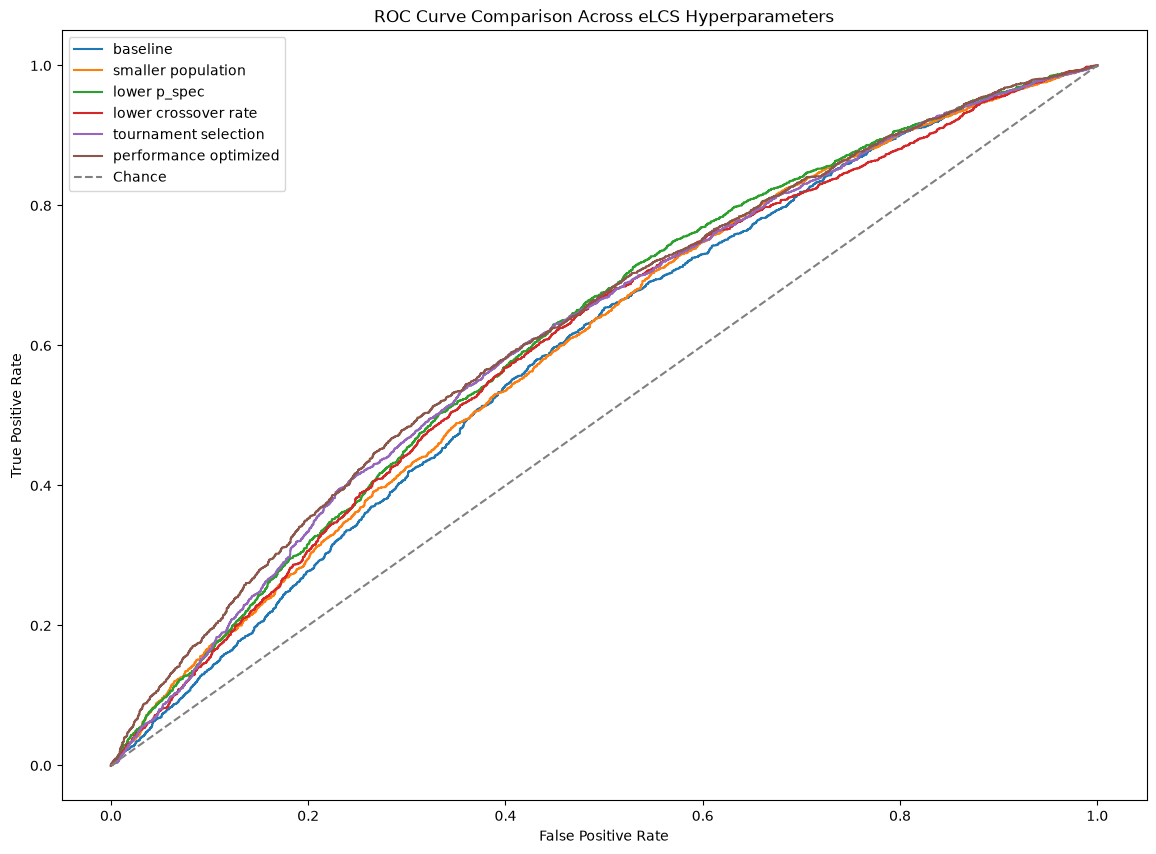

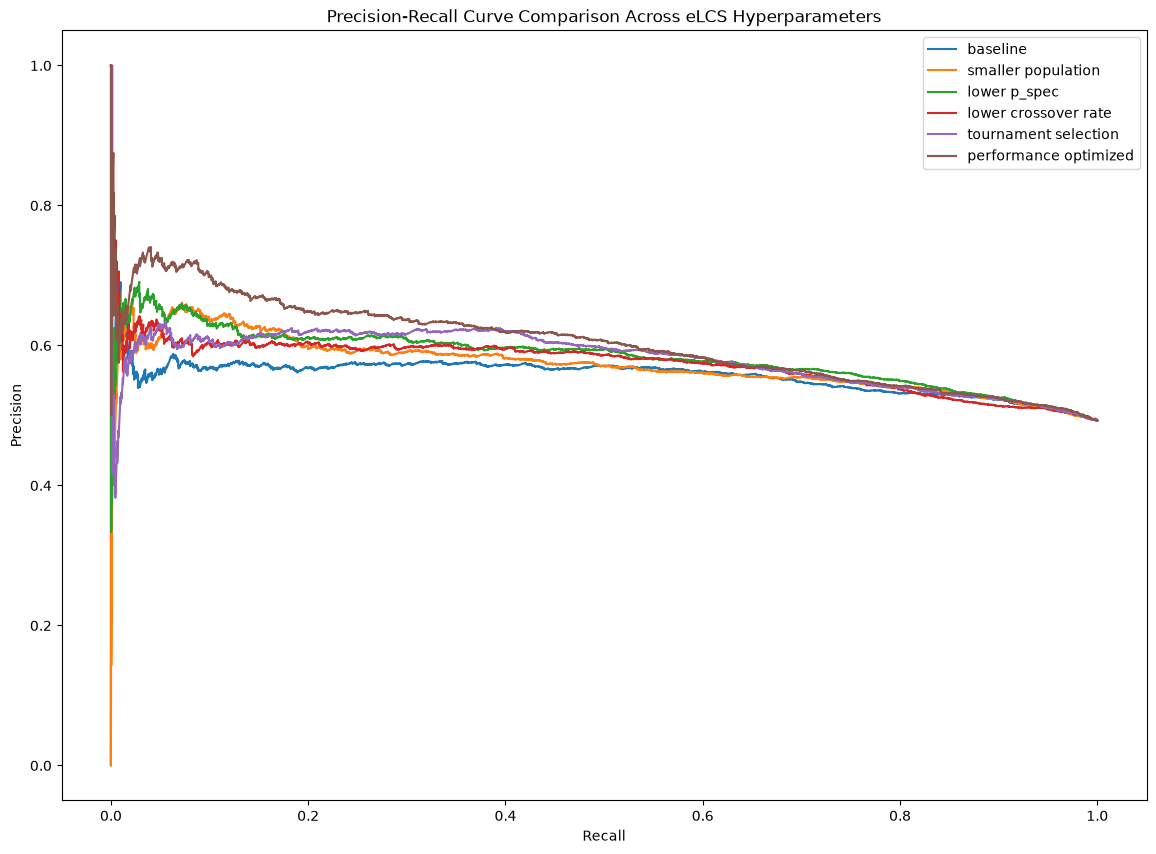

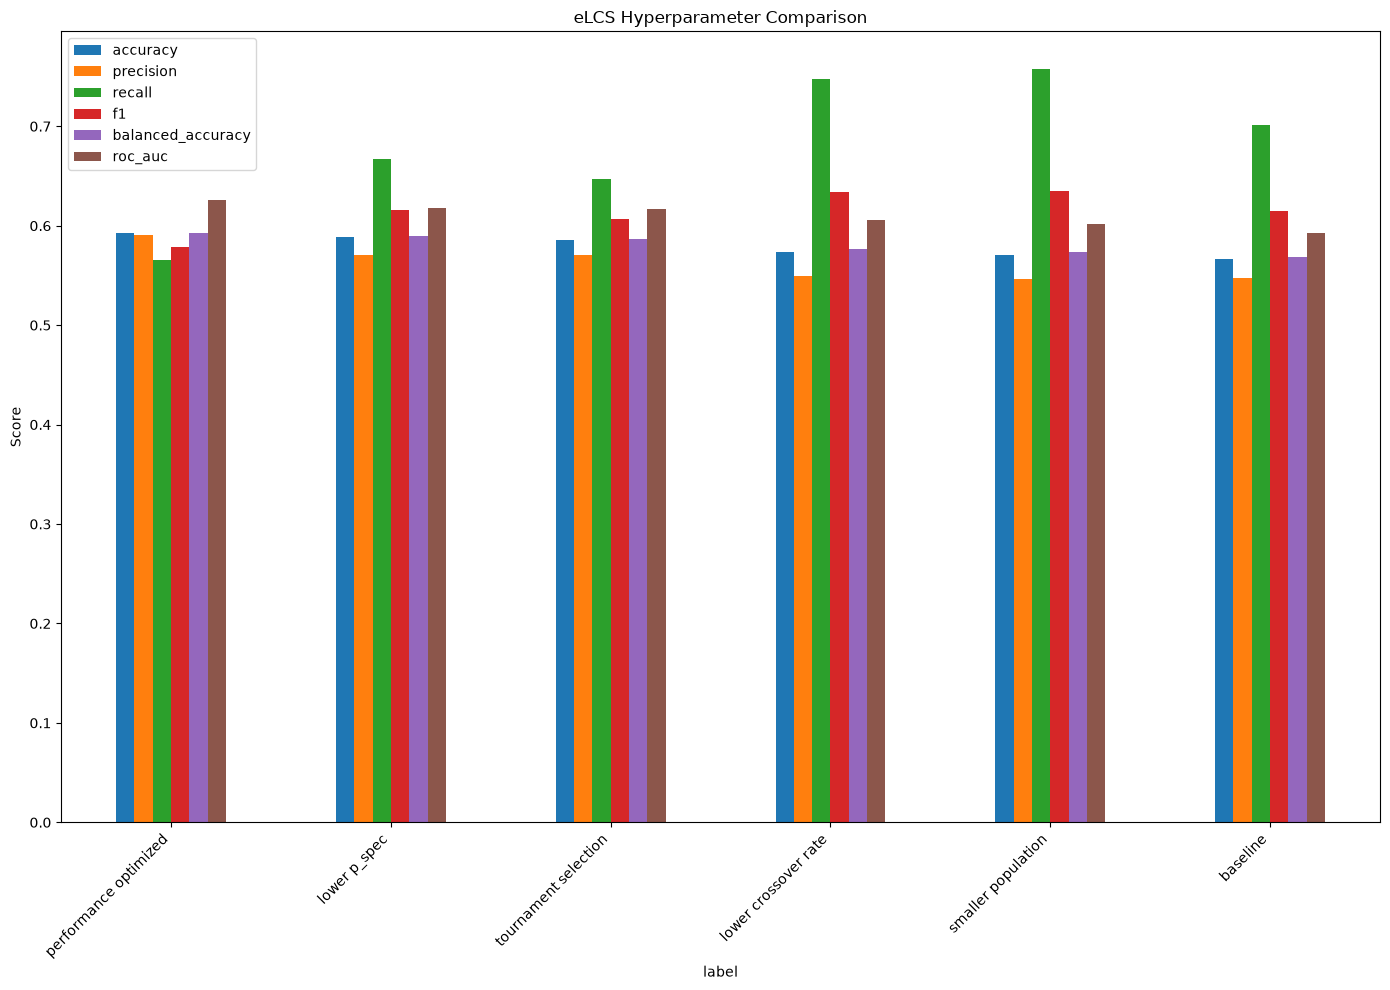

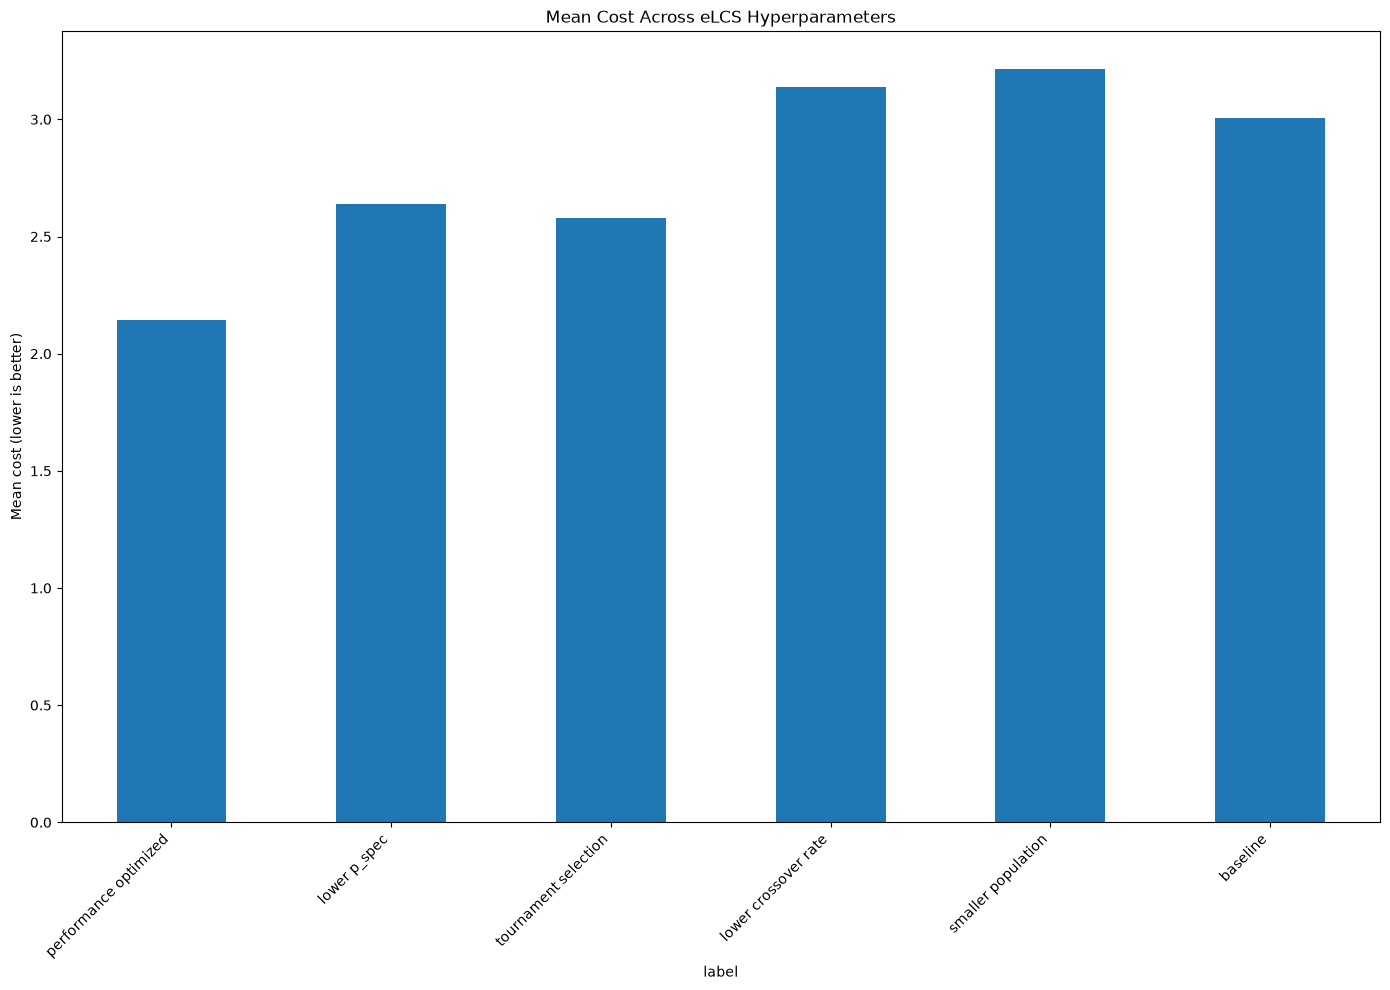

In [348]:
# Define eLCS parameter configurations to compare.
# Parameters and defaults per "Overview of all scikit-eLCS initialization parameters
# and default values" (eLCS User Guide.ipynb): learning_iterations=10000, N=1000,
# p_spec=0.5, nu=5, chi=0.8, mu=0.04, selection_method="tournament", acc_sub=0.99,
# theta_GA=25. The guide recommends leaving chi/mu/theta_GA/theta_del/theta_sub/beta/
# delta/init_fit/fitness_reduction/theta_sel at their defaults, so the grid below
# varies the parameters the guide identifies as impactful: learning_iterations, N,
# p_spec, nu, selection_method, and acc_sub.

# eLCS performs rule reduction during training: do_GA_subsumption is enabled by default,
# and N limits the microclassifier population through deletion. The guide documents
# exporting the final rules, but not a separate post-fit rule-pruning API.

# Process
# 1. Uncomment and run all combinations
# 2. Find the top 4 ranked items
# 3. Use the parameters to create new combination
# 4. Add the combination to the elcs_param_grid.

training_iterations = 2000
track_accuracy_while_fit = False

elcs_param_grid = {
    f"baseline": dict(
        learning_iterations=training_iterations,
        N=1000,
        p_spec=0.5,
        nu=5,
        chi=0.8,
        mu=0.04,
        track_accuracy_while_fit=track_accuracy_while_fit,
        random_state=42,
    ),
    # "larger population (N=2000)": dict(
    #     learning_iterations=training_iterations,
    #     N=2000,
    #     p_spec=0.5,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.04,
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    "smaller population": dict(
        learning_iterations=training_iterations,
        N=500,
        p_spec=0.5,
        nu=5,
        chi=0.8,
        mu=0.04,
        track_accuracy_while_fit=track_accuracy_while_fit,
        random_state=42,
    ),
    "lower p_spec": dict(
        learning_iterations=training_iterations,
        N=1000,
        p_spec=0.3,
        nu=5,
        chi=0.8,
        mu=0.04,
        track_accuracy_while_fit=track_accuracy_while_fit,
        random_state=42,
    ),
    # "higher p_spec (p_spec=0.7)": dict(
    #     learning_iterations=training_iterations,
    #     N=1000,
    #     p_spec=0.7,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.04,
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    # "noise-tolerant nu (nu=1)": dict(
    #     learning_iterations=training_iterations,
    #     N=1000,
    #     p_spec=0.5,
    #     nu=1,
    #     chi=0.8,
    #     mu=0.04,
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    # "higher mutation rate (mu=0.1)": dict(
    #     learning_iterations=training_iterations,
    #     N=1000,
    #     p_spec=0.5,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.1,
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    "lower crossover rate": dict(
        learning_iterations=training_iterations,
        N=1000,
        p_spec=0.5,
        nu=5,
        chi=0.5,
        mu=0.04,
        track_accuracy_while_fit=track_accuracy_while_fit,
        random_state=42,
    ),
    "tournament selection": dict(
        learning_iterations=training_iterations,
        N=1000,
        p_spec=0.5,
        nu=5,
        chi=0.8,
        mu=0.04,
        selection_method="tournament",
        theta_sel=0.2,
        track_accuracy_while_fit=track_accuracy_while_fit,
        random_state=42,
    ),
    # "tournament selection, theta_sel=0.8": dict(
    #     learning_iterations=training_iterations,
    #     N=1000,
    #     p_spec=0.5,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.04,
    #     selection_method="tournament",
    #     theta_sel=0.8,
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    # "roulette selection": dict(
    #     learning_iterations=training_iterations,
    #     N=1000,
    #     p_spec=0.5,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.04,
    #     selection_method="roulette",
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    # "roulette selection, n=2000": dict(
    #     learning_iterations=training_iterations,
    #     N=2000,
    #     p_spec=0.5,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.04,
    #     selection_method="roulette",
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    # "stricter subsumption (acc_sub=1.0)": dict(
    #     learning_iterations=training_iterations,
    #     N=1000,
    #     p_spec=0.5,
    #     nu=5,
    #     chi=0.8,
    #     mu=0.04,
    #     acc_sub=1.0,
    #     do_correct_set_subsumption=True,
    #     track_accuracy_while_fit=track_accuracy_while_fit,
    #     random_state=42,
    # ),
    "performance optimized": dict(
        learning_iterations=len(
            X_train_raw
        ),  # Higher value gives better accuracy during test runs
        N=500,
        p_spec=0.3,
        nu=5,
        chi=0.5,
        mu=0.04,
        selection_method="tournament",
        theta_sel=0.2,
        track_accuracy_while_fit=track_accuracy_while_fit,
        random_state=42,
    ),
}

elcs_hypertune_results = hypertune_elcs(
    elcs_param_grid,
    X_train_raw,
    y_train,
    X_test_raw,
    y_test,
)

In [349]:
# Pool rules from the top 3 ranked configurations, then rank all rules together.
# Rule strength is a heuristic: fitness multiplied by classifier numerosity.
top_configurations = elcs_hypertune_results.head(3)
rules_from_top_configurations = []

for _, configuration in top_configurations.iterrows():
    configuration_rank = int(configuration["Rank"])
    configuration_label = configuration["label"]
    rule_model = eLCS(**elcs_param_grid[configuration_label])
    rule_model.fit(
        X_train_raw.to_numpy(),
        y_train.to_numpy(),
    )

    rule_file = f"../data/export/elcs_rules_rank_{configuration_rank}.csv"
    rule_model.export_final_rule_population(
        headerNames=X_train_raw.columns.to_numpy(),
        className="Completed",
        filename=rule_file,
        DCAL=False,
    )

    rule_population = pd.read_csv(rule_file)
    rule_population["Rule Strength"] = (
        rule_population["Fitness"] * rule_population["Numerosity"]
    )
    rule_population.insert(0, "Configuration Rank", configuration_rank)
    rule_population.insert(1, "Configuration", configuration_label)
    rules_from_top_configurations.append(rule_population)

combined_rule_population = pd.concat(
    rules_from_top_configurations,
    ignore_index=True,
)
important_elcs_rules = (
    combined_rule_population.sort_values(
        ["Rule Strength", "Accuracy", "Match Count"],
        ascending=False,
    )
    .head(3)
    .copy()
    .reset_index(drop=True)
)
important_elcs_rules.insert(0, "Rule Rank", range(1, len(important_elcs_rules) + 1))

print("Top 3 rules pooled across the top 3 ranked eLCS configurations:")
display(important_elcs_rules.style.hide(axis="index"))
print(
    "Exported rule populations to ../data/export/elcs_rules_rank_1.csv through rank_3.csv."
)

Top 3 rules pooled across the top 3 ranked eLCS configurations:


Rule Rank,Configuration Rank,Configuration,Education_Level,Internet_Connection_Quality,Payment_Mode,Fee_Paid,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,Completed,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count,Rule Strength
1,2,lower p_spec,3.0,1.0,2.0,#,"-5.624852647846182,-1.3747021433522661","-3.2889108668370977,0.7856877113096081",#,#,#,#,#,"-1.0186677693245423,2.5987453756230163",#,#,#,#,#,0.000000,1.000000,1.000000,2,184.000000,1743,1400,0.352941,nan,2,2,2.000000
2,1,performance optimized,#,1.0,#,#,"-5.195226274113044,-1.3747021433522661","-3.6793184901159903,4.240289409728841",#,"-4.035552354760786,5.590265574835282","-2.4467671307353855,1.009518401316285",#,"-2.6485583273881077,4.287861442561573",#,"-0.9594701477811054,1.9701414806996145",#,#,#,"-5.056147733556324,1.5926052574299432",0.000000,1.000000,1.000000,1,126.680000,23604,23335,0.470588,0.002258,6,6,1.000000
3,1,performance optimized,#,#,#,#,"-6.134728450973855,-1.0862229126721088",#,"-4.155257366998794,4.061249838545165",#,#,"-2.7069702424571247,1.3465637976299079","-2.6691296243441673,4.287861442561573",#,#,#,#,#,#,0.000000,1.000000,1.000000,1,110.800000,23696,23675,0.235294,0.001952,5,5,1.000000


Exported rule populations to ../data/export/elcs_rules_rank_1.csv through rank_3.csv.


#### Using conventional models 


Logistic Regression
-------------------
          accuracy: 0.6033
         precision: 0.6010
            recall: 0.5815
                f1: 0.5911
 balanced_accuracy: 0.6030
         mean_cost: 2.1097
           roc_auc: 0.6446
           prc_auc: 0.6209
Confusion Matrix:
[[1900 1142]
 [1238 1720]]

Decision Tree
-------------
          accuracy: 0.5335
         precision: 0.5270
            recall: 0.5250
                f1: 0.5260
 balanced_accuracy: 0.5334
         mean_cost: 2.5575
           roc_auc: 0.5334
           prc_auc: 0.6431
Confusion Matrix:
[[1648 1394]
 [1405 1553]]

Random Forest (2000 trees)
--------------------------
          accuracy: 0.5972
         precision: 0.5949
            recall: 0.5730
                f1: 0.5838
 balanced_accuracy: 0.5968
         mean_cost: 2.1338
           roc_auc: 0.6324
           prc_auc: 0.6069
Confusion Matrix:
[[1888 1154]
 [1263 1695]]

Conventional classifiers ranked by balanced accuracy:


Rank,label,accuracy,precision,recall,f1,balanced_accuracy,mean_cost,roc_auc,prc_auc
1,Logistic Regression,0.603333,0.600978,0.581474,0.591065,0.603032,2.109667,0.644642,0.620895
2,Random Forest (2000 trees),0.597167,0.594946,0.573022,0.583778,0.596833,2.133833,0.632444,0.606895
3,Decision Tree,0.533500,0.526977,0.525017,0.525995,0.533383,2.557500,0.533383,0.643080


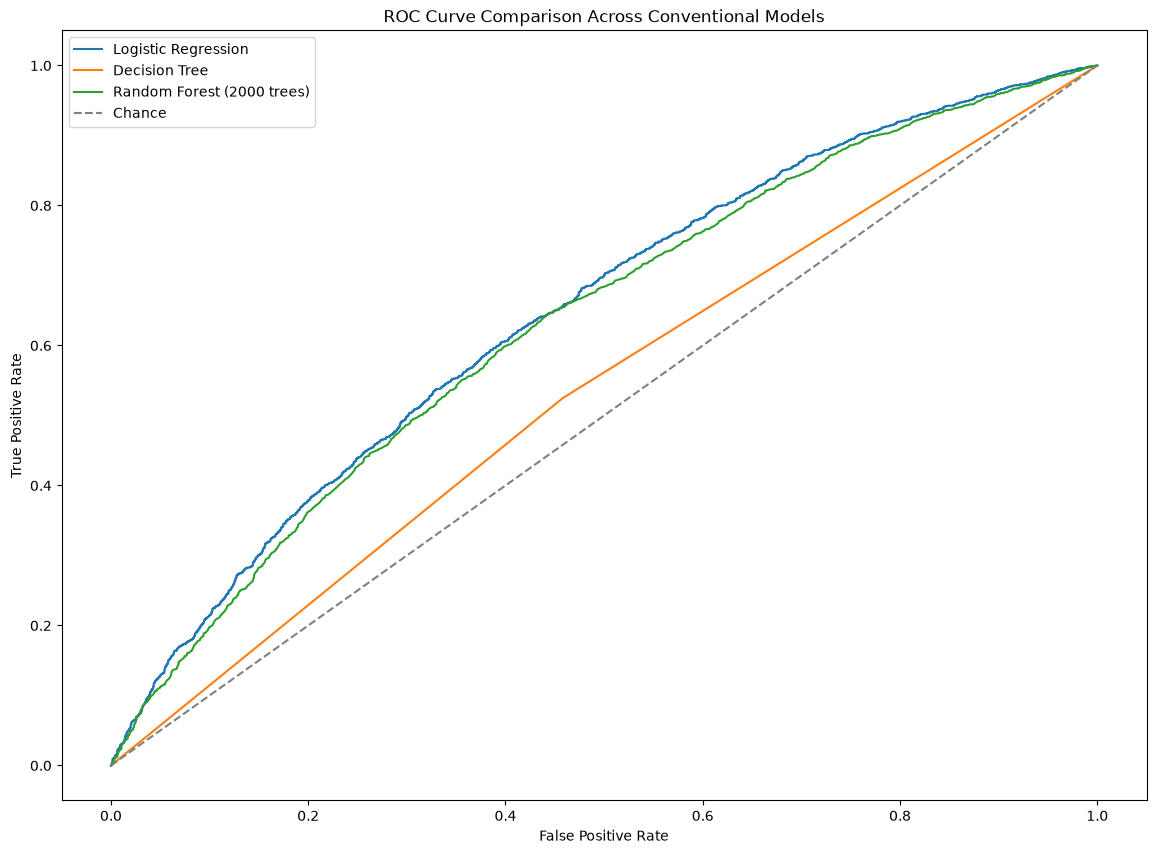

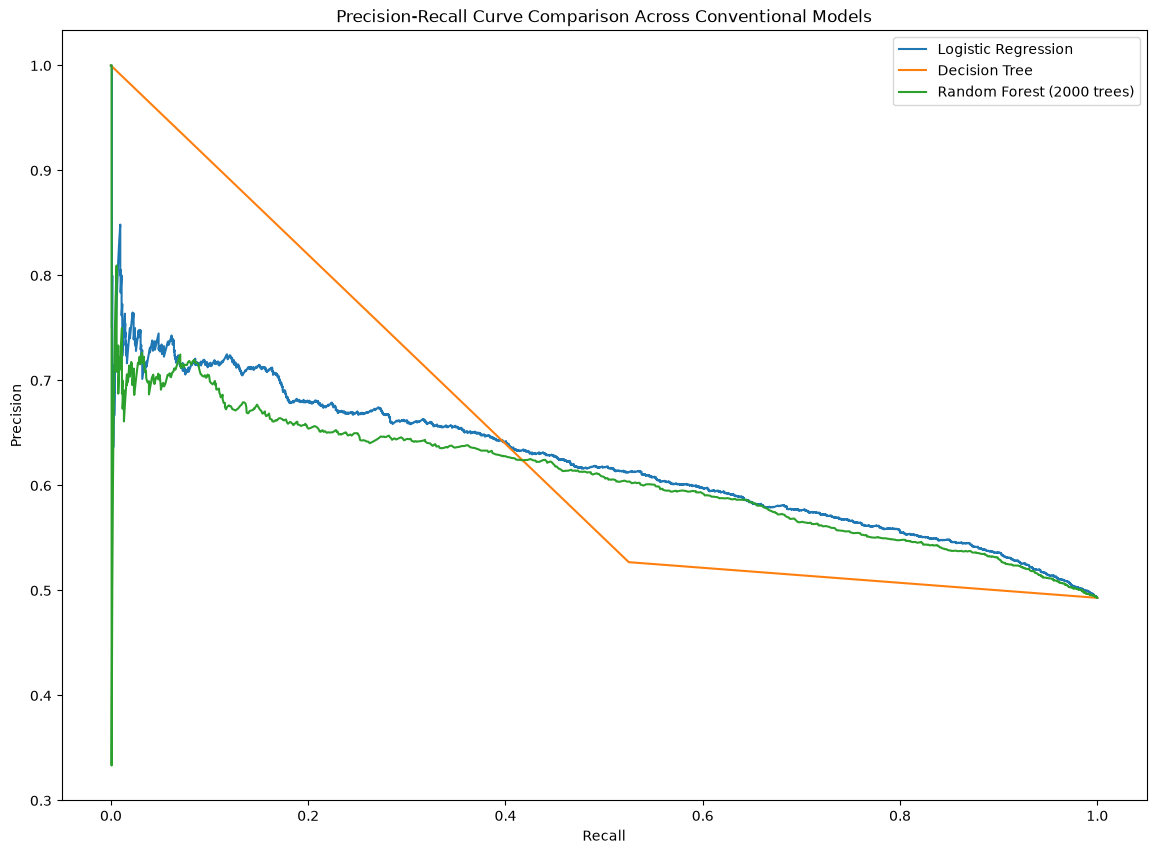

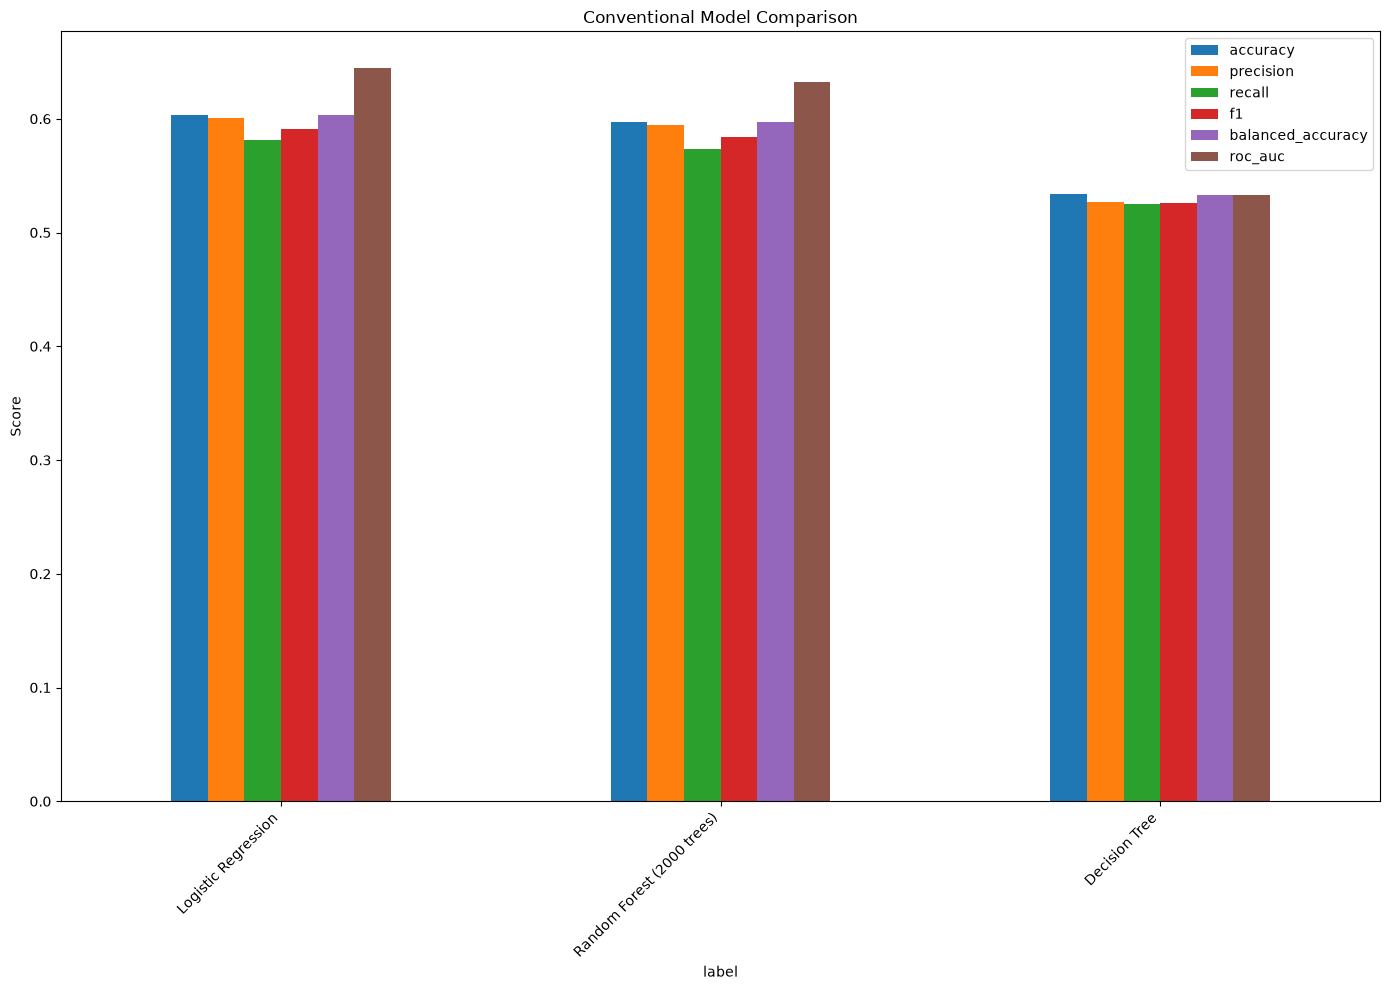

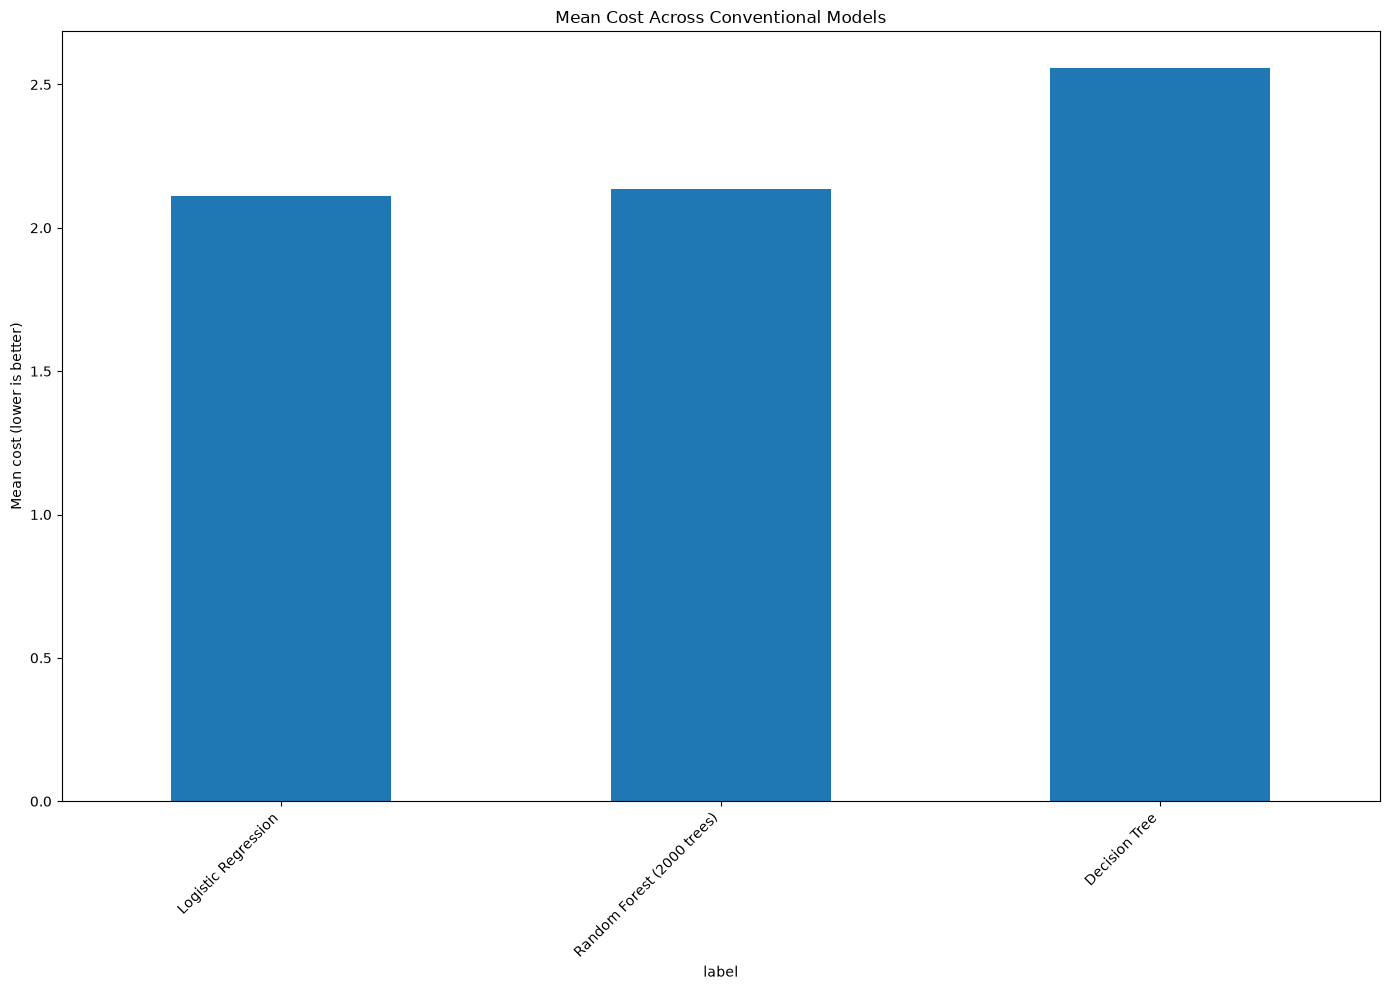

In [350]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

conventional_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (2000 trees)": RandomForestClassifier(
        n_estimators=2000,
        random_state=42,
        n_jobs=-1,
    ),
}

conventional_results = []
conventional_roc_curves = {}
conventional_prc_curves = {}
false_negative_cost = 10.0
false_positive_cost = 1.0

for model_label, model in conventional_models.items():
    model.fit(X_train_raw, y_train)
    y_pred = model.predict(X_test_raw)
    probabilities = model.predict_proba(X_test_raw)
    positive_class_index = list(model.classes_).index(1)
    positive_probabilities = probabilities[:, positive_class_index]

    false_negatives = ((y_test == 0) & (y_pred == 1)).sum()
    false_positives = ((y_test == 1) & (y_pred == 0)).sum()
    mean_cost = (
        false_negative_cost * false_negatives + false_positive_cost * false_positives
    ) / len(y_test)

    fpr, tpr, _ = roc_curve(y_test, positive_probabilities)
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, positive_probabilities
    )

    metrics = {
        "label": model_label,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "mean_cost": mean_cost,
        "roc_auc": auc(fpr, tpr),
        "prc_auc": auc(recall_curve, precision_curve),
    }
    conventional_results.append(metrics)
    conventional_roc_curves[model_label] = (fpr, tpr)
    conventional_prc_curves[model_label] = (recall_curve, precision_curve)

    print(f"\n{model_label}")
    print("-" * len(model_label))
    for metric_name, metric_value in metrics.items():
        if metric_name != "label":
            print(f"{metric_name:>18}: {metric_value:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

conventional_results_df = (
    pd.DataFrame(conventional_results)
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
conventional_results_df.insert(0, "Rank", range(1, len(conventional_results_df) + 1))

print("\nConventional classifiers ranked by balanced accuracy:")
display(conventional_results_df.style.hide(axis="index"))

plt.figure(figsize=(14, 10))
for model_label, (fpr, tpr) in conventional_roc_curves.items():
    plt.plot(fpr, tpr, label=model_label)
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Conventional Models")
plt.legend()
plt.show()

plt.figure(figsize=(14, 10))
for model_label, (recall_curve, precision_curve) in conventional_prc_curves.items():
    plt.plot(recall_curve, precision_curve, label=model_label)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison Across Conventional Models")
plt.legend()
plt.show()

conventional_metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "roc_auc",
]
conventional_results_df.set_index("label")[conventional_metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 10),
)
plt.ylabel("Score")
plt.title("Conventional Model Comparison")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

conventional_results_df.set_index("label")["mean_cost"].plot(
    kind="bar", figsize=(14, 10)
)
plt.ylabel("Mean cost (lower is better)")
plt.title("Mean Cost Across Conventional Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Rank 1 eLCS and conventional model comparison:


Rank,label,accuracy,precision,recall,f1,balanced_accuracy,mean_cost,roc_auc,prc_auc
1,Logistic Regression,0.603333,0.600978,0.581474,0.591065,0.603032,2.109667,0.644642,0.620895
2,Random Forest (2000 trees),0.597167,0.594946,0.573022,0.583778,0.596833,2.133833,0.632444,0.606895
3,eLCS (Rank 1: performance optimized),0.592833,0.590893,0.565923,0.578138,0.592462,2.145667,0.625595,0.602653
4,Decision Tree,0.533500,0.526977,0.525017,0.525995,0.533383,2.557500,0.533383,0.643080


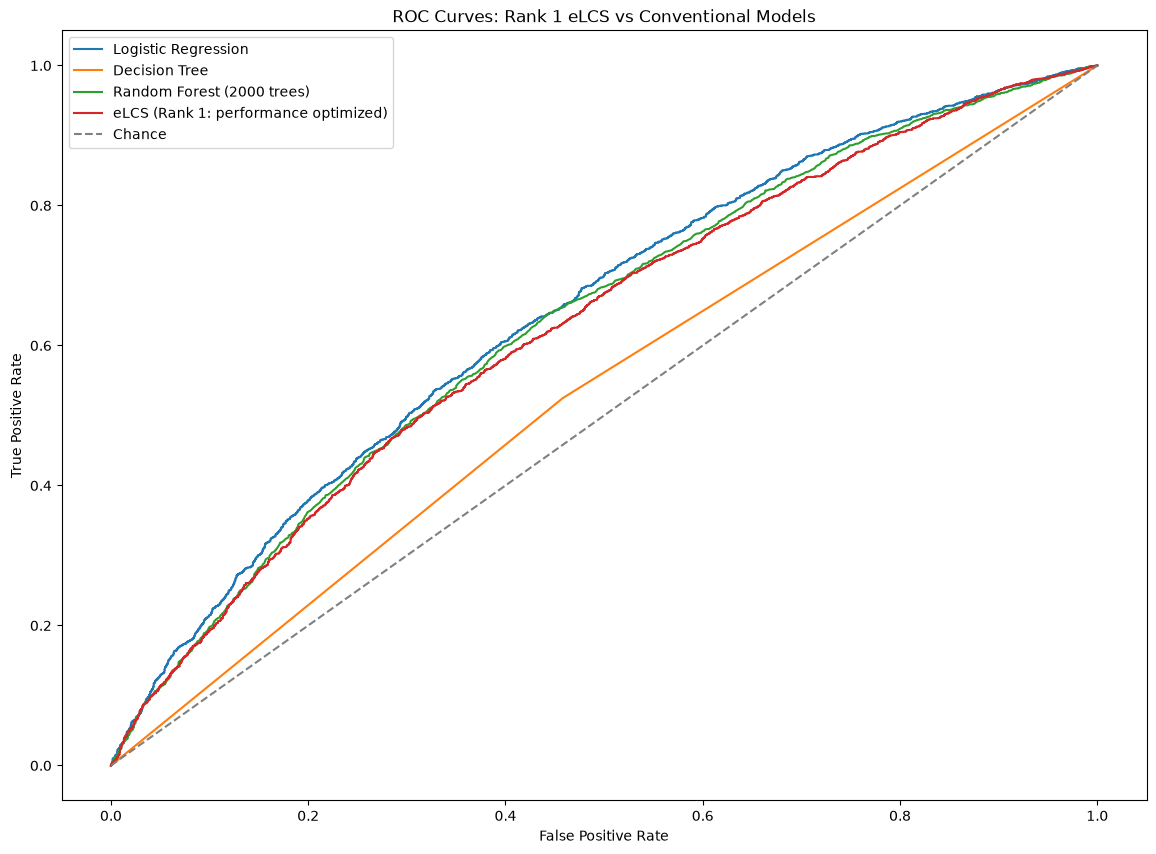

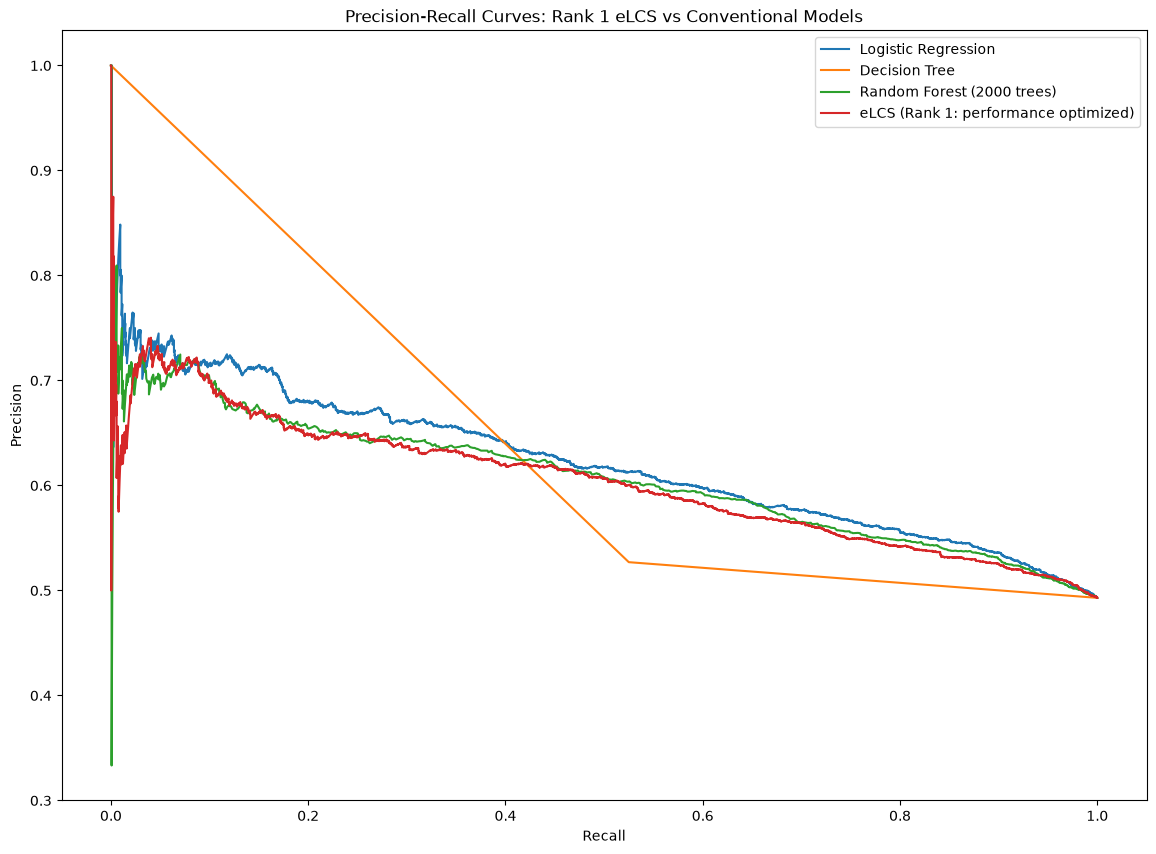

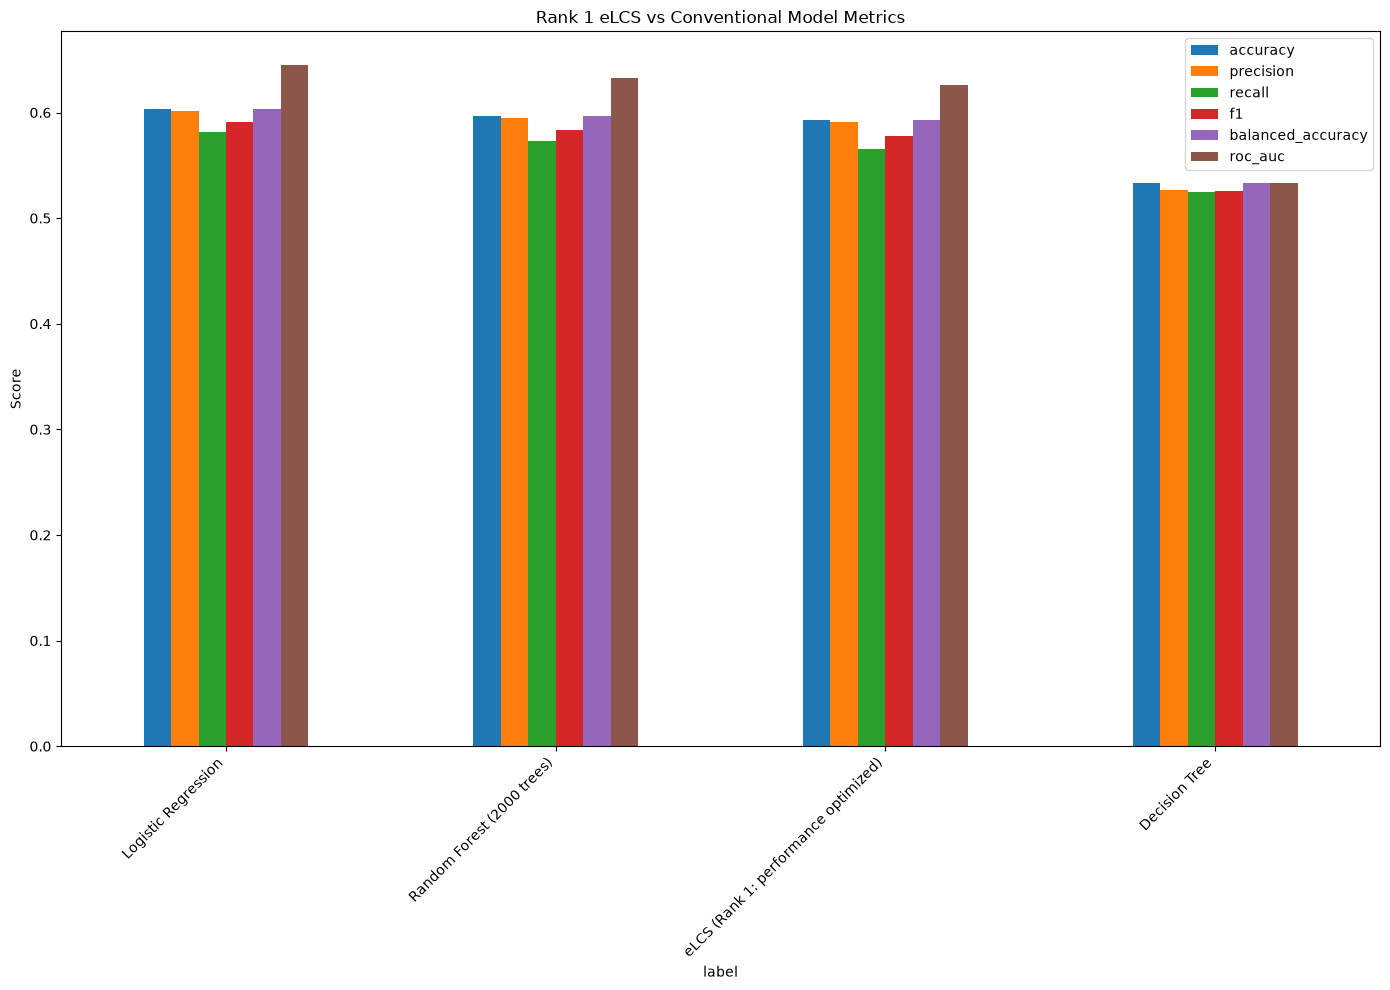

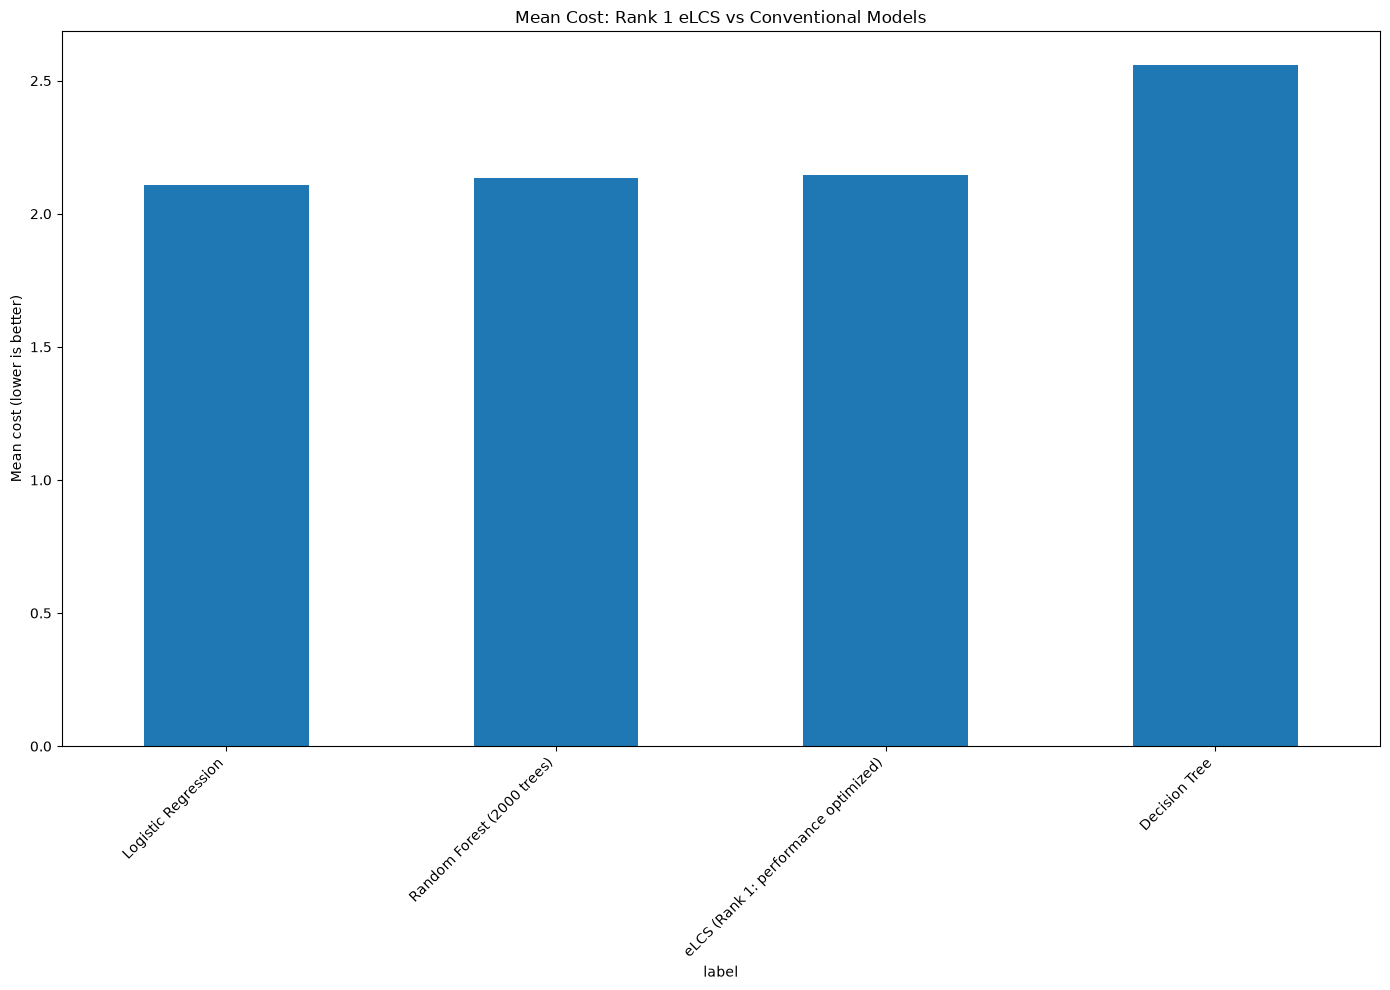

In [351]:
# Reuse prior metrics and ROC/PRC curves; no model refits are needed for this comparison.
previous_best_elcs_label = globals().get("best_elcs_label")
top_elcs_configuration = elcs_hypertune_results.sort_values("Rank").iloc[0]
best_elcs_label = top_elcs_configuration["label"]
eLCS_comparison_label = f"eLCS (Rank 1: {best_elcs_label})"

cached_elcs_roc_curves = elcs_hypertune_results.attrs.get("roc_curves", {})
if best_elcs_label not in cached_elcs_roc_curves:
    legacy_elcs_fpr = globals().get("elcs_fpr")
    legacy_elcs_tpr = globals().get("elcs_tpr")
    if (
        previous_best_elcs_label == best_elcs_label
        and legacy_elcs_fpr is not None
        and legacy_elcs_tpr is not None
    ):
        cached_elcs_roc_curves[best_elcs_label] = (
            legacy_elcs_fpr,
            legacy_elcs_tpr,
        )
        elcs_hypertune_results.attrs["roc_curves"] = cached_elcs_roc_curves
    else:
        raise RuntimeError(
            "ROC curves are not cached in elcs_hypertune_results. "
            "Re-run the eLCS hyperparameter tuning cell to populate them."
        )

cached_elcs_prc_curves = elcs_hypertune_results.attrs.get("prc_curves", {})
if best_elcs_label not in cached_elcs_prc_curves:
    raise RuntimeError(
        "PRC curves are not cached in elcs_hypertune_results. "
        "Re-run the updated eLCS hyperparameter tuning cell to populate them."
    )

comparison_metric_columns = [
    "label",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "mean_cost",
    "roc_auc",
    "prc_auc",
]
rank1_elcs_metrics = top_elcs_configuration[comparison_metric_columns].to_dict()
rank1_elcs_metrics["label"] = eLCS_comparison_label
comparison_results = [rank1_elcs_metrics, *conventional_results]
comparison_roc_curves = conventional_roc_curves.copy()
comparison_roc_curves[eLCS_comparison_label] = cached_elcs_roc_curves[best_elcs_label]
comparison_prc_curves = conventional_prc_curves.copy()
comparison_prc_curves[eLCS_comparison_label] = cached_elcs_prc_curves[best_elcs_label]

combined_model_results = (
    pd.DataFrame(comparison_results)
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
combined_model_results.insert(0, "Rank", range(1, len(combined_model_results) + 1))

print("\nRank 1 eLCS and conventional model comparison:")
display(combined_model_results.style.hide(axis="index"))

plt.figure(figsize=(14, 10))
for model_label, (fpr, tpr) in comparison_roc_curves.items():
    plt.plot(fpr, tpr, label=model_label)
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Rank 1 eLCS vs Conventional Models")
plt.legend()
plt.show()

plt.figure(figsize=(14, 10))
for model_label, (recall_curve, precision_curve) in comparison_prc_curves.items():
    plt.plot(recall_curve, precision_curve, label=model_label)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: Rank 1 eLCS vs Conventional Models")
plt.legend()
plt.show()

comparison_metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "roc_auc",
]
combined_model_results.set_index("label")[comparison_metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 10),
)
plt.ylabel("Score")
plt.title("Rank 1 eLCS vs Conventional Model Metrics")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

combined_model_results.set_index("label")["mean_cost"].plot(
    kind="bar", figsize=(14, 10)
)
plt.ylabel("Mean cost (lower is better)")
plt.title("Mean Cost: Rank 1 eLCS vs Conventional Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()